In [1]:
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
import pickle
import math
from scipy.optimize import curve_fit as curve_fit

from open_iris_client import EyeData, EyesData, ExtraData, Point

root = Path('/home/dan/work/CNS-OpenIrisDAC')


In [2]:
def edgenerator(filename):
    with open(filename,'rb') as f:
        while True:
            try:
                ed = pickle.load(f)
                yield ed
            except EOFError:
                break       

def load_cal_data(filename):
    n = 0
    for ed in edgenerator(filename):
        n += 1
    print(f"Found {n} records in {filename}")

    # now allocate arrays and fill them
    datashape = (n,2)
    frame_number_array = np.zeros(n)
    pupil_array = np.zeros(datashape)
    cr_array = np.zeros(datashape)
    p4_array = np.zeros(datashape)
    pupil_scatter_array = np.zeros(datashape)
    cr_scatter_array = np.zeros(datashape)
    p4_scatter_array = np.zeros(datashape)
    scatter_count = 0
    counter = 0
    button_up = True
    button_list=[]  # (index,x,y)
    button_is_pressed = False
    framesig_present = False
    framesig_on = False
    framesig_on_at = 0

    for ed in edgenerator(filename):
        data_ok = True
        if ed.left.pupil.x == 0 or ed.left.pupil.y == 0:
            pupil_array[counter,:] = np.nan
            data_ok = False
        else:
            pupil_array[counter,0] = ed.left.pupil.x
            pupil_array[counter,1] = ed.left.pupil.y
        frame_number_array[counter] = ed.left.frame_number
        if ed.left.cr.x == -100 or ed.left.cr.y == -100:
            cr_array[counter,:] = np.nan
            data_ok = False
        else:
            cr_array[counter,0] = ed.left.cr.x
            cr_array[counter,1] = ed.left.cr.y
        if ed.left.p4.x == 820 or ed.left.p4.y == -100:
            p4_array[counter,:] = np.nan
            data_ok = False
        else:
            p4_array[counter,0] = ed.left.p4.x
            p4_array[counter,1] = ed.left.p4.y

        # if ed.extra.ints[0] != 12:
        #     print(f"frame at {counter}: {ed.extra.ints[0]}")
            
        button_is_pressed = ed.extra.ints[8] & 0x1
        framesig_present = ed.extra.ints[0] & 0x1

        if not framesig_on:
            if framesig_present:
                framesig_on_at = counter
                framesig_on = True
        else:
            # framesig_on is True, meaning the last time through the FRAME signal was present.
            # We only need to check if framesig is not present this time.
            if not framesig_present:
                framesig_on = False

        if button_up:
            if button_is_pressed:
                button_up = False
                if data_ok:
                    button_list.append((counter, ed.extra.doubles[7], ed.extra.doubles[8], framesig_on_at))
                    #print(f"{counter}: {ed.extra.doubles[6]}, {ed.extra.doubles[7]}")
                    pupil_scatter_array[scatter_count,:] = [ed.left.pupil.x, ed.left.pupil.y]
                    cr_scatter_array[scatter_count,:] = [ed.left.cr.x, ed.left.cr.y]
                    p4_scatter_array[scatter_count,:] = [ed.left.p4.x, ed.left.p4.y]
                    scatter_count += 1
                # else:
                #     print('button down no data')
        else:
            if not button_is_pressed:
                button_up = True
    
        counter += 1        


    print(f"Found {counter} frames")
    print(f"Found {scatter_count} button presses")

    return (pupil_array, cr_array, p4_array, button_list)

def plot_sig(p0, p1, p4, l, n=1):
    #       generate points for plots....
    
    L = len(l)
    datashape = (L,2)
    p0xy = np.zeros(datashape)
    p1xy = np.zeros(datashape)
    p4xy = np.zeros(datashape)
    for i, (ind,fx,fy) in enumerate(l):
        #print(f"{ind}, {fx}, {fy}")
        p0xy[i, :] = np.mean(p0[ind:ind+n, :], axis=0)
        p1xy[i, :] = np.mean(p1[ind:ind+n, :], axis=0)
        p4xy[i, :] = np.mean(p4[ind:ind+n, :], axis=0)


    f, axes = plt.subplots(2, 1, figsize=(10,10))
    axes[0].scatter(p0xy[:L,0], p0xy[:L,1], color='blue', label='pupil')
    axes[0].scatter(p1xy[:L,0], p1xy[:L,1], color='red', label='cr')
    axes[0].scatter(p4xy[:L,0], p4xy[:L,1], color='green', label='p4')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_title('Scatter Plot of Eye Tracking Data')
    axes[0].legend()

    cr_sig = p1xy-p0xy
    dpi_sig = p4xy-p1xy
    axes[1].scatter(cr_sig[:L,0], cr_sig[:L,1], color='blue', label='CR')
    axes[1].scatter(dpi_sig[:L,0], dpi_sig[:L,1], color='red', label='DPI')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_title('Raw CR, DPI Tracking Vectors')
    axes[1].legend()

    plt.show()
def plot_xy_interval(xy, istart, nbefore, nafter):

    # generate plot x value, call it 't' to eliminate confusion
    t = np.arange(-nbefore, nafter)

    f, ax = plt.subplots(figsize=(10,10))
    
    xcolor = 'tab:red'
    ycolor = 'tab:blue'

    ax.set_xlabel('frame')
    ax.set_ylabel('Xp', color=xcolor)
    ax.tick_params(axis='y', labelcolor=xcolor)
    ax.set_ylim((0,720))

    ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis
    ax2.set_ylabel('Yp', color=ycolor)  # we already handled the x-label with ax1
    ax2.tick_params(axis='y', labelcolor=ycolor)
    ax2.set_ylim(0,450)

    plt.axvline(x = 0, color = 'g')

    for i in istart:
        ax.plot(t, xy[i-nbefore:i+nafter,0], color=xcolor)
        ax2.plot(t, xy[i-nbefore:i+nafter,1], color=ycolor)
 
    f.tight_layout()
    plt.show() 

def plot_from_frame(ax, xy, iframe, ibutton, ntotal,xlim=(0,720),ylim=(0,450), vlinepm=(0,0)):
    """Plot x and y, starting at iframe, with ntotal frames. Vertical line drawn at ibutton, and at vlinepm[0] and [1] below and above, respectively, if those are not (0,0). 

    Args:
        ax (_type_): axis for x
        xy (_type_): axis for y
        iframe (_type_): first frame to plot
        ibutton (_type_): frame where button was hit
        ntotal (_type_): icnlude this many frames
        xlim (tuple, optional): Limits, these are pixel values. Defaults to (0,720).
        ylim (tuple, optional): Limits, pixel values. Defaults to (0,450).
    """

    # generate plot x value, call it 't' to eliminate confusion
    t = np.arange(0, ntotal)
    
    xcolor = 'tab:red'
    ycolor = 'tab:blue'

    ax.set_xlabel('frame')
    ax.set_ylabel('Xp', color=xcolor)
    ax.tick_params(axis='y', labelcolor=xcolor)
    ax.set_ylim(xlim)

    ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis
    ax2.set_ylabel('Yp', color=ycolor)  # we already handled the x-label with ax1
    ax2.tick_params(axis='y', labelcolor=ycolor)
    ax2.set_ylim(ylim)

    plt.axvline(x = ibutton-iframe, color = 'g')
    if vlinepm[0] != 0:
        plt.axvline(x = ibutton-iframe-vlinepm[0], color = 'g')
    if vlinepm[1] != 0:
        plt.axvline(x = ibutton-iframe+vlinepm[1], color = 'g')



    ax.plot(t, xy[iframe:iframe+ntotal,0], color=xcolor)
    ax2.plot(t, xy[iframe:iframe+ntotal,1], color=ycolor)
 
    # f.tight_layout()
    # plt.show() 

def plot_velocity(ax, xy, iframe, ibutton, ntotal,xlim=(-50,50),ylim=(-50,50),iframes=(0,0)):

    # generate plot x value, call it 't' to eliminate confusion
    t = np.arange(0, ntotal)
    v = np.diff(xy, axis=0)
    xcolor = 'tab:red'
    ycolor = 'tab:blue'

    ax.set_xlabel('frame')
    ax.set_ylabel('Xp', color=xcolor)
    ax.tick_params(axis='y', labelcolor=xcolor)
    ax.set_ylim(xlim)

    ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis
    ax2.set_ylabel('Yp', color=ycolor)  # we already handled the x-label with ax1
    ax2.tick_params(axis='y', labelcolor=ycolor)
    ax2.set_ylim(ylim)

    
    if iframes==(0,0):
        plt.axvline(x = ibutton-iframe, color = 'g')
        ax.plot(t, v[iframe:iframe+ntotal,0], color=xcolor)
        ax2.plot(t, v[iframe:iframe+ntotal,1], color=ycolor)
    else:
        t = np.arange(iframes[0]-ibutton,iframes[1]-ibutton)
        print(f"{iframes[0]},{iframes[1]}")
        ax.plot(t, v[iframes[0]:iframes[1],0], color=xcolor)
        ax2.plot(t, v[iframes[0]:iframes[1],1], color=ycolor)
 
    # f.tight_layout()
    # plt.show() 

def plot_hist(axX, axY, xy, ibutton, nbefore, nafter, nbins=20):

    xcolor = 'tab:red'
    ycolor = 'tab:blue'

    # Use value at ibutton as center of hist. We take nbins to be both sides, width is 1px. range(xy[ibutton]-nbins, xy[ibusson]+nbins)

    xb = xy[ibutton,0]
    yb = xy[ibutton,1]
    axX.hist(xy[ibutton-nbefore:ibutton+nafter, 0], bins=np.arange(xb-nbins, xb+nbins), color=xcolor)
    axY.hist(xy[ibutton-nbefore:ibutton+nafter, 1], bins=np.arange(yb-nbins, yb+nbins), color=ycolor)



def plot_xyvelh(xy,iframe,ibutton, nframes=1000, nbefore=50,nafter=50,title=""):
    fig = plt.figure(figsize=(12,6))
    if title:
        fig.suptitle(title)
    axs = fig.subplots(1,4,squeeze=True)
    fig.tight_layout()
    plot_from_frame(axs[0], xy, iframe, ibutton, nframes, xlim=(-200,200),ylim=(-200,200), vlinepm=(nbefore,nafter))
    plot_velocity(axs[1], xy, iframe, ibutton, nframes, xlim=(-25,25),ylim=(-25,25), iframes=(ibutton-nbefore,ibutton+nafter))
    plot_hist(axs[2], axs[3], xy, ibutton, nbefore=nbefore, nafter=nafter)
    plt.show()


In [3]:
def check_velocity(xy, ind, nbefore, nafter, vmax):
    """Check that velocity (in x and y separately) is less than vmax in the range defined by ind, nbefore, and nafter.

    Args:
        xy (numpy array nframes x 2): xy values
        ind (int): index of button press
        nbefore (int): nframes before button press to include in tests
        nafter (int): nframes after button press blah blah
        vmax (float): max velocity 
    """
    v = np.diff(xy, axis=0)
    return np.all(np.abs(v[ind-nbefore:ind+nafter,:]) < vmax)

# Source - https://stackoverflow.com/a/75598551
# Posted by cottontail
# Retrieved 2026-07-08, License - CC BY-SA 4.0

def transform(xy, x_gain, y_gain, degrees):
    # xy is an avg x,y crsig values
    # return nd.array[xtrans,ytrans] from transform using params   
    p = Point(xy[0] * x_gain, xy[1] * y_gain)
    trans = p.rotate(degrees * math.pi / 180)
    #print(f"xy {xy[0]},{xy[1]} {x_gain} {y_gain} {degrees} trans {trans.x},{trans.y}")
    return np.array([trans.x, trans.y])

def transform_wrapper(xydata, x_gain, y_gain, degrees):
    # if xydata.shape[0] % 2 != 0:
    #     raise ValueError("xy data should have even number of elements.")
    #xyview =xydata.reshape((2,xydata.shape[0]//2))
    #print(f"transform_wrapper xydata {np.shape(xydata)} view {np.shape(xyview)}")
    pdata = np.apply_along_axis(transform, 0, xydata, x_gain, y_gain, degrees)
    #print(f"transform_wrapper pdata {pdata.ravel()}")
    return pdata.ravel()
    

In [15]:
(pupil_array, cr_array, p4_array, button_list) = load_cal_data(filename='./cal94.pkl')
crsig = cr_array - pupil_array
dpisig = p4_array - cr_array


nframes=1000    # for xy and velocity plots, go this many frames from the initial onset frame of the stim
nbefore=50
nafter=50
vmax=10
doplots = False

goodlist=[] # tuples of xav,yav,xv,yv for good trials - those that pass the velocity test
# for i in range(8):
#     (ind,vx,vy,f) = button_list[i]
for (ind,vx,vy,f) in button_list:
    # this just checks that there is enough data to plot x and y
    if ind+nframes < np.shape(crsig)[0]:
        # actual data checks to try out
        check1 = check_velocity(crsig,ind,nbefore,nafter,vmax=vmax)
        if check1 and vx<999 and vy < 999:
            m = np.mean(crsig[ind-nbefore:ind+nafter,:], axis=0)    # this is an ndarray
            goodlist.append((m,vx,vy))
            mytitle=f"{vx},{vy},{str(check1)}"
            if doplots:
                plot_xyvelh(crsig, f, ind, nframes=nframes, nbefore=nbefore,nafter=nafter,title=mytitle)
if doplots:
    plt.show()

Found 31644 records in ./cal94.pkl
Found 31644 frames
Found 37 button presses


In [20]:
l00data=[]  # measurements at (0,0)
lxdata=[]    # list of arrays to stack
lydata=[]   # ydata here is the expected degrees - voltage is just a multiple

# split out the data from (0,0) = this will be used to find offset
for (m,vx,vy) in goodlist:
    if vx==0 and vy==0:
        #print(f"{vx},{vy},{m[0]},{m[1]}")
        l00data.append(m)
    else:
        #print(f"{vx},{vy},{m[0]},{m[1]}")
        lxdata.append(m)
        lydata.append(np.array([vx,vy]))


print(f"goodlist {len(goodlist)} (0,0) {len(l00data)} (other) {len(lxdata)}")

xy00data = np.stack(l00data)
print("mean bias ", xy00data.mean(axis=0))
xdata=(np.stack(lxdata) - xy00data.mean(axis=0)).T
ydata=np.stack(lydata).T.ravel()
print(f"list has {len(goodlist)} xdata shape {np.shape(xdata)} ydata shape {np.shape(ydata)}")
# print(np.stack(lydata))
# print(xdata)

# print a nice list of things. Shapes are all mixed up.
# ydatatmp = ydata.reshape((2, len(ydata)//2))
# for i in range(len(goodlist)):
#     print(f"{i}: {ydatatmp[0,i]},{ydatatmp[1][i]} raw {xdata[0][i]},{xdata[1][i]}")



goodlist 32 (0,0) 21 (other) 11
mean bias  [-4.79686013 40.27313453]
list has 32 xdata shape (2, 11) ydata shape (22,)


In [14]:
transform([21,1.5],.4,.4,-3.8)

array([8.42129629, 0.04198017])

[[ 13.52081918   1.46481195]
 [-12.21485434  -1.60510489]
 [ 13.02575814   1.0502839 ]
 [-12.05798453  -1.57402488]
 [ -0.22842215  11.72327737]
 [  1.51178414 -12.11777472]
 [ -0.19282615  11.33951501]
 [  1.01568002 -12.56327674]
 [ -0.84823356  10.96399591]
 [ 13.51791787   1.1098356 ]
 [-12.16553061  -1.77384238]]
[ 5. -5.  5. -5.  0.  0.  0.  0.  0.  5. -5.  0.  0.  0.  0.  5. -5.  5.
 -5.  5.  0.  0.]
popt [ 0.3865514   0.41282373 -5.30055968]
pcov [[2.09463905e-05 1.76775296e-08 1.68901254e-04]
 [1.76775296e-08 3.11717303e-05 8.30499821e-05]
 [1.68901254e-04 8.30499821e-05 7.93507119e-01]]
pdata shape (22,)
(2, 11)
(2, 11)


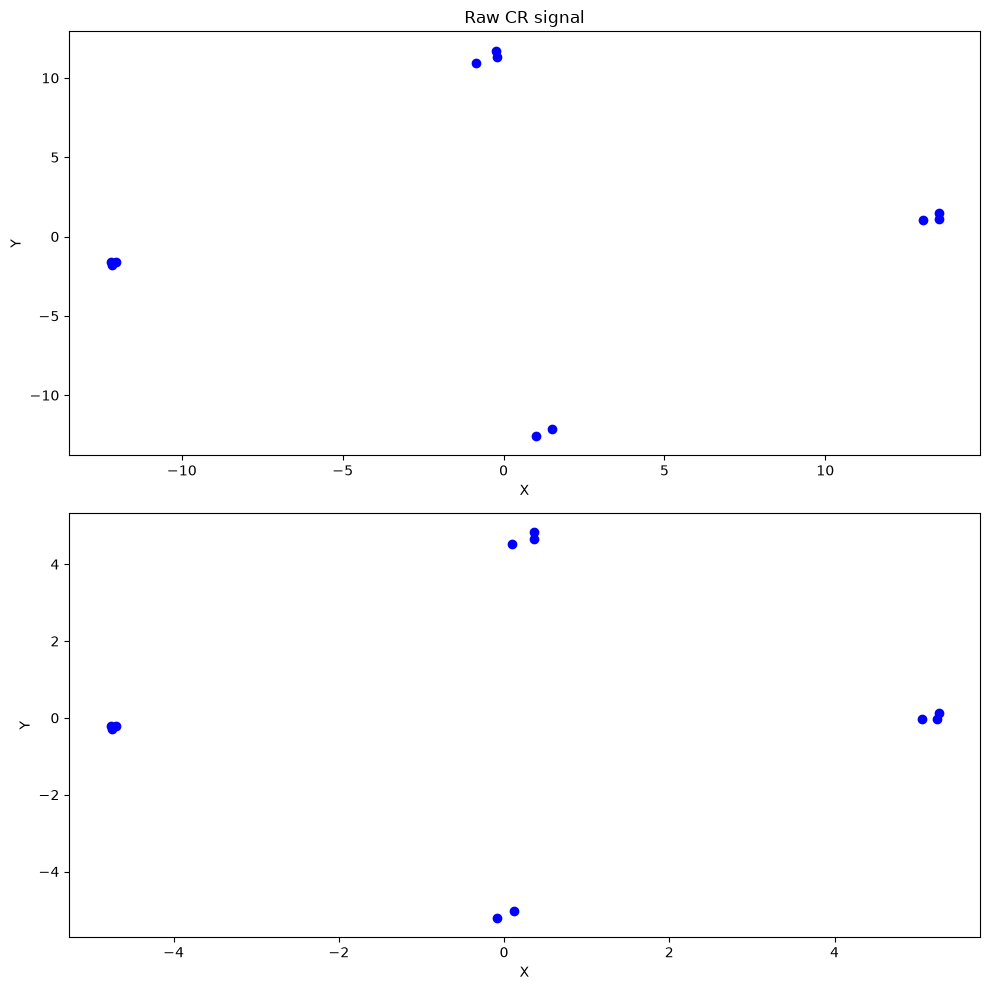

In [21]:

# fit
# initial guess for x_gain, y_gain, degrees
p0 = np.array([.2,.2,0])

# limits for same
low_limits = np.array([0.1, 0.1, -10])
hi_limits = np.array([5, 5, 10])

print(xdata.T)
print(ydata.T)
popt, pcov = curve_fit(transform_wrapper, xdata, ydata, p0, bounds=(low_limits, hi_limits))
print("popt",popt)
print("pcov",pcov)

# get transform of input data, plot it
pdata = transform_wrapper(xdata, popt[0], popt[1], popt[2])
print(f"pdata shape {np.shape(pdata)}")
result = pdata.reshape((2,pdata.shape[0]//2))
print(np.shape(result))
print(np.shape(xdata))



f, axes = plt.subplots(2, 1, figsize=(10,10))
axes[0].scatter(xdata[0,:], xdata[1,:], color='blue', label='raw')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('Raw CR signal')
axes[1].scatter(result[0,:], result[1,:], color='blue', label='transformed')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
f.tight_layout()
plt.show()



In [ ]:
from calibrator_analyzer import CalibratorAnalyzer

ana = CalibratorAnalyzer()
for ed in edgenerator('./cal95.pkl'):
    ana.step(ed)


In [ ]:
ana.ana_cr()